In [68]:
%load_ext autoreload
%autoreload 2
from superbit_lensing.plotter import ClusterRedSequenceAnalysis
import superbit_lensing.utils as utils
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
cluster_name = 'Abell3411'
datadir = "/Users/leilaohashi/gitrepo/leila_superbit_lensing/" # Change to your data directory!
# utils.TARGET_LIST = os.path.join(datadir, "SuperBIT_target_list.csv")
# analyzer = ClusterRedSequenceAnalysis(cluster_name, datadir=datadir, delz=0.02)
# analyzer.load_data()

# smoothing, bins, etc. parameters
xray_contour_percentiles = [70, 99] # change to desired percentiles for x-ray contours
xray_contour_number = 3 # number of contour levels to save (e.g., 3 means 3 levels: 70th, 80th, 90th percentiles)
hist_bins = 50 # change bins here for 2D histogram of actual members
hist_sigma = 2 # change smoothing for 2D histogram of actual members
members_contour_percentiles = [95, 99] # change to desired percentiles for actual member contours
members_contour_number = 3 # number of contour levels to save for actual members (e.g., 3 means 3 levels: 70th, 80th, 90th percentiles)
conv_contour_percentiles = [75, 99] # change to desired percentiles for actual member contours
conv_contour_number = 3 # number of contour levels to save for actual members (e.g., 3 means 3 levels: 70th, 80th, 90th percentiles)

Contour level 1 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//x_ray_image/Abell3411/contours_ra_dec/contour_level_1.csv
Contour level 2 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//x_ray_image/Abell3411/contours_ra_dec/contour_level_2.csv
Contour level 3 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//x_ray_image/Abell3411/contours_ra_dec/contour_level_3.csv


Set MJD-END to 56339.619792 from DATE-END'. [astropy.wcs.wcs]
/var/folders/7s/vm2shg2x4yq_97b8jbnb1y8r0000gn/T/ipykernel_43984/3567514803.py:48: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for i, collection in enumerate(cs.collections):


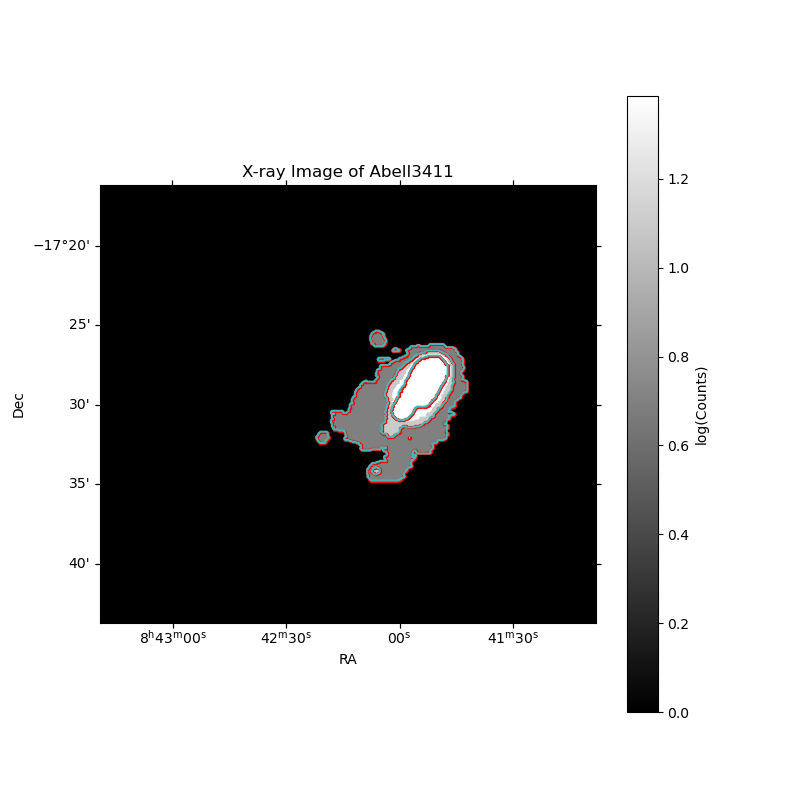

X-ray image saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//x_ray_image/Abell3411/Abell3411_xray_image.png


In [70]:

import os
import csv
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from scipy.ndimage import gaussian_filter
from astropy.wcs import WCS

fits_path = f"{datadir}/data/xray/{cluster_name}_xray_image.fits"
if not os.path.exists(fits_path):
    print(f"X-ray image for {cluster_name} not found at {fits_path}.")

# Open the image
xray_hdu = fits.open(fits_path)[0]
xray_data = xray_hdu.data
xray_data = np.array(xray_data)
xray_header = xray_hdu.header
wcs = WCS(xray_header)



# Plot the image
smoothed_counts = gaussian_filter(xray_data, sigma=5)
log_image = np.log1p(smoothed_counts)
vmin, vmax = np.percentile(log_image, [1, 99])

plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)
im = ax.imshow(log_image, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label='log(Counts)')
ax.set_title(f'X-ray Image of {cluster_name}')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')

# Contours
contour_levels_xray = np.linspace(np.percentile(log_image, xray_contour_percentiles[0]), np.percentile(log_image, xray_contour_percentiles[1]), xray_contour_number)
# Contour Colors
colors = ['cyan', 'cyan', 'cyan']
cs = ax.contour(log_image, levels=contour_levels_xray, colors=colors, linewidths=1.5, alpha=0.7)

# save contours
save_dir = f'{datadir}/x_ray_image/{cluster_name}/contours_ra_dec'
os.makedirs(save_dir, exist_ok=True)

all_xray_vertices_ra = []
all_xray_vertices_dec = []

for i, collection in enumerate(cs.collections):

    contour_save_path = os.path.join(save_dir, f'contour_level_{i+1}.csv')

    with open(contour_save_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['RA', 'Dec'])

        for path in collection.get_paths():
            contour_points = path.vertices
            ax.scatter(contour_points[:, 0], contour_points[:, 1], s=2, color='red', alpha=0.7)
            ra_dec = wcs.wcs_pix2world(contour_points, 0)
            all_xray_vertices_ra.extend(ra_dec[:,0])
            all_xray_vertices_dec.extend(ra_dec[:,1])
            writer.writerows(ra_dec)
    print(f"Contour level {i+1} saved to {contour_save_path}")

all_xray_vertices_ra = np.array(all_xray_vertices_ra)
all_xray_vertices_dec = np.array(all_xray_vertices_dec)

# Save and show the image
save_path = f"{datadir}/x_ray_image/{cluster_name}/{cluster_name}_xray_image.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300)
plt.show()

print(f"X-ray image saved to {save_path}")

Contour level 1 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//x_ray_image/Abell3411/contours_ra_dec/contour_level_1.csv
Contour level 2 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//x_ray_image/Abell3411/contours_ra_dec/contour_level_2.csv
Contour level 3 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//x_ray_image/Abell3411/contours_ra_dec/contour_level_3.csv


Set MJD-END to 56339.619792 from DATE-END'. [astropy.wcs.wcs]
/var/folders/7s/vm2shg2x4yq_97b8jbnb1y8r0000gn/T/ipykernel_43984/4012044319.py:57: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for i, collection in enumerate(cs.collections):


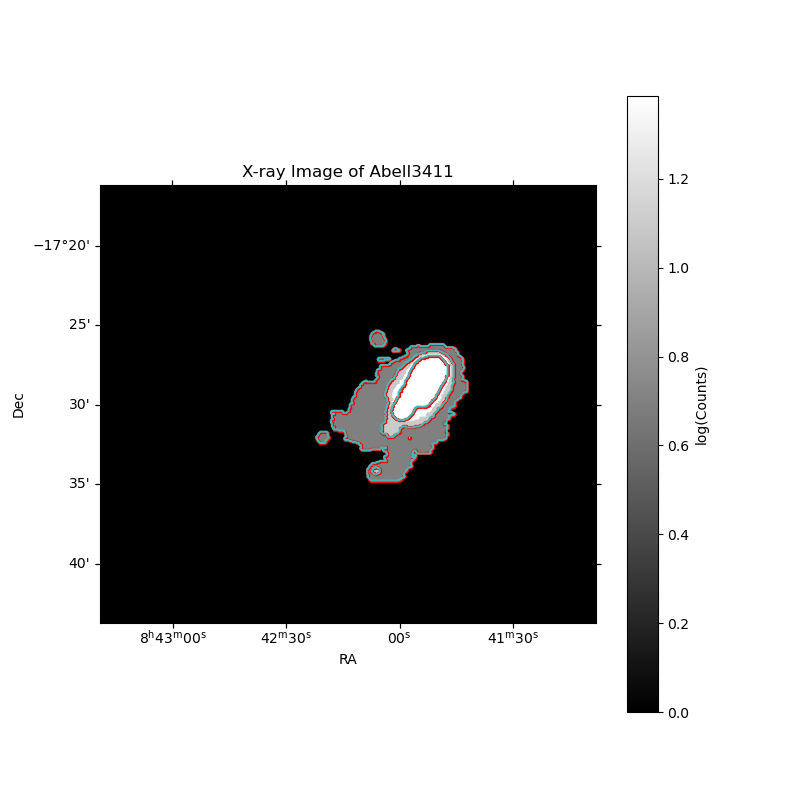

Click on the figure to create a polygon.
Press the 'esc' key to start a new polygon.
Try holding the 'shift' key to move all of the vertices.
Try holding the 'ctrl' key to move a single vertex.


In [77]:
%matplotlib widget
import os
import csv
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from scipy.ndimage import gaussian_filter
from astropy.wcs import WCS
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
import pandas as pd
from shapely.geometry import Point, Polygon

# x ray image and contours


fits_path = f"{datadir}/data/xray/{cluster_name}_xray_image.fits"
if not os.path.exists(fits_path):
    print(f"X-ray image for {cluster_name} not found at {fits_path}.")

# Open the image
xray_hdu = fits.open(fits_path)[0]
xray_data = xray_hdu.data
xray_data = np.array(xray_data)
xray_header = xray_hdu.header
xray_wcs = WCS(xray_header)



# Plot the image
smoothed_counts = gaussian_filter(xray_data, sigma=5)
log_image = np.log1p(smoothed_counts)
vmin, vmax = np.percentile(log_image, [1, 99])

plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=xray_wcs)
im = ax.imshow(log_image, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label='log(Counts)')
ax.set_title(f'X-ray Image of {cluster_name}')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')

# Contours
contour_levels_xray = np.linspace(np.percentile(log_image, xray_contour_percentiles[0]), np.percentile(log_image, xray_contour_percentiles[1]), xray_contour_number)

# Contour Colors
colors = ['cyan', 'cyan', 'cyan']
cs = ax.contour(log_image, levels=contour_levels_xray, colors=colors, linewidths=1.5, alpha=0.7)

# save contours
save_dir = f'{datadir}/x_ray_image/{cluster_name}/contours_ra_dec'
os.makedirs(save_dir, exist_ok=True)

all_xray_vertices_ra = []
all_xray_vertices_dec = []

for i, collection in enumerate(cs.collections):

    contour_save_path = os.path.join(save_dir, f'contour_level_{i+1}.csv')

    with open(contour_save_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['RA', 'Dec'])

        for path in collection.get_paths():
            contour_points = path.vertices
            ax.scatter(contour_points[:, 0], contour_points[:, 1], s=2, color='red', alpha=0.7)
            ra_dec = xray_wcs.wcs_pix2world(contour_points, 0)
            all_xray_vertices_ra.extend(ra_dec[:,0])
            all_xray_vertices_dec.extend(ra_dec[:,1])
            writer.writerows(ra_dec)
    print(f"Contour level {i+1} saved to {contour_save_path}")

all_xray_vertices_ra = np.array(all_xray_vertices_ra)
all_xray_vertices_dec = np.array(all_xray_vertices_dec)

# interactive polygon to remove point sources of error and save new contour vertices

selector = PolygonSelector(ax, lambda *args: None)

# Add three vertices
verts = []

def onselect(v):
    global verts
    verts = v
    print("Selected vertices:", verts)
selector = PolygonSelector(ax, onselect, useblit=True, props=dict(color='red', linestyle='-', linewidth=2, alpha=0.5), handle_props=dict(marker='o', markersize=5, mec='red', mfc='red', alpha=0.5))

plt.show()

print("Click on the figure to create a polygon.")
print("Press the 'esc' key to start a new polygon.")
print("Try holding the 'shift' key to move all of the vertices.")
print("Try holding the 'ctrl' key to move a single vertex.")

In [78]:
print(verts)

[(np.float64(321.95161290322574), np.float64(186.46774193548382)), (np.float64(260.5322580645161), np.float64(192.22580645161284)), (np.float64(304.67741935483866), np.float64(227.73387096774186))]


In [79]:
# convert verts to ra and dec
verts = xray_wcs.wcs_pix2world(verts, 0) # convert selected vertices to RA/Dec
# point in polygon analysis
def point_in_polygon(all_xray_vertices_ra, all_xray_vertices_dec, verts):
    point_in_polygon_list = []
    polygon = Polygon(verts)
    for ra, dec in zip(all_xray_vertices_ra, all_xray_vertices_dec):
        point = Point(ra, dec)
        if polygon.contains(point):
            point_in_polygon_list.append((ra, dec))
    return point_in_polygon_list
point_in_polygon_list = point_in_polygon(all_xray_vertices_ra, all_xray_vertices_dec, verts)
print(point_in_polygon_list)


[(np.float64(130.47813711957738), np.float64(-17.52291149134673)), (np.float64(130.4769907618761), np.float64(-17.52181799127306)), (np.float64(130.4769907618761), np.float64(-17.52181799127306)), (np.float64(130.4758442326849), np.float64(-17.52181781763502)), (np.float64(130.4746978957263), np.float64(-17.520724304405853)), (np.float64(130.4746978957263), np.float64(-17.520724304405853)), (np.float64(130.47355157258843), np.float64(-17.519630784599112)), (np.float64(130.47355157258843), np.float64(-17.519630784599112)), (np.float64(130.472405263272), np.float64(-17.518537258216885)), (np.float64(130.472405263272), np.float64(-17.518537258216885)), (np.float64(130.47125875488106), np.float64(-17.518537058271132)), (np.float64(130.47011224651845), np.float64(-17.51853685173981)), (np.float64(130.46896596487878), np.float64(-17.517443305640942)), (np.float64(130.46896596487878), np.float64(-17.517443305640942)), (np.float64(130.4678196970635), np.float64(-17.516349752972577)), (np.float

In [72]:
# convert verts to ra and dec
verts = xray_wcs.wcs_pix2world(verts, 0) # convert selected vertices to RA/Dec

# point in polygon analysis
def point_in_polygon(all_xray_vertices_ra, all_xray_vertices_dec, verts):
    point_in_polygon_list = []
    polygon = Polygon(verts)
    for ra, dec in zip(all_xray_vertices_ra, all_xray_vertices_dec):
        point = Point(ra, dec)
        if polygon.contains(point):
            point_in_polygon_list.append((ra, dec))
    return point_in_polygon_list
point_in_polygon_list = point_in_polygon(all_xray_vertices_ra, all_xray_vertices_dec, verts)
all_xray_points = list(zip(all_xray_vertices_ra, all_xray_vertices_dec))
for x in point_in_polygon_list:
    point = [x[0], x[1]]
    all_xray_points.remove(point)
all_xray_points = np.array(all_xray_points)
print(all_xray_points)

# Plot the image
plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=xray_wcs)
im = ax.imshow(log_image, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label='log(Counts)')
ax.set_title(f'X-ray Image of {cluster_name}')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')

ax.scatter(all_xray_points[:, 0], all_xray_points[:, 1], s=2, color='red', alpha=0.7)

all_xray_vertices_ra_updated = np.array(all_xray_points[:,0])
all_xray_vertices_dec_updated = np.array(all_xray_points[:,1])

ValueError: list.remove(x): x not in list

In [16]:
from astropy.table import Table, vstack, hstack
import numpy as np
from esutil import htm
from astropy.io import fits
import os

cluster_name = "Abell3411"
color_path = f"{datadir}data/color_mags/"
mcal_path = f"{datadir}mcal/"

color_cat_path = os.path.join(
    color_path, cluster_name, f"{cluster_name}_colors_mags.fits")
mcal_cat_path = os.path.join(
    mcal_path, cluster_name, f"{cluster_name}_b_mcal_combined.fits")

colors_mags = Table.read(color_cat_path, memmap=True)
mcal = Table.read(mcal_cat_path, memmap=True)

mcal_matcher = htm.Matcher(16, ra=mcal['ra'], dec=mcal['dec'])

colors_ind, mcal_ind, dist = mcal_matcher.match(
    ra=colors_mags['ra'], dec=colors_mags['dec'],
    maxmatch=1, radius=0.8/3600)
print(len(dist))

mcal = mcal[mcal_ind]
colors_mags = colors_mags[colors_ind]

g1 = mcal['g_noshear'][:,0]
g2 = mcal['g_noshear'][:,1]
colors_mags.add_columns([g1, g2], names=["g1_noshear", "g2_noshear"])
 
wg = colors_mags['is_red_sequence']
print(np.sum(wg))

outname = os.path.splitext(color_cat_path)[0] + '_clean_nors.fits'
colors_mags[wg].write(outname, format='fits', overwrite=True)

all_ra = colors_mags['ra']
all_dec = colors_mags['dec']
all_ra = np.array(all_ra)
all_dec = np.array(all_dec)
all_pixels_x = wcs.wcs_world2pix(all_ra, all_dec, 0)[0]
all_pixels_y = wcs.wcs_world2pix(all_ra, all_dec, 0)[1]
colors_mags['XWIN_IMAGE'] = all_pixels_x
colors_mags['YWIN_IMAGE'] = all_pixels_y

6869
1057


Reading regions from /Users/leilaohashi/gitrepo/leila_superbit_lensing/data/region_files/Abell3411_b_starmask_physical.reg
Found 73 regions
Converting regions to polygons...
Converted 73 polygons
Using XWIN_IMAGE and YWIN_IMAGE as pixel coordinate columns
Checking object 0/1057
Checking object 1000/1057


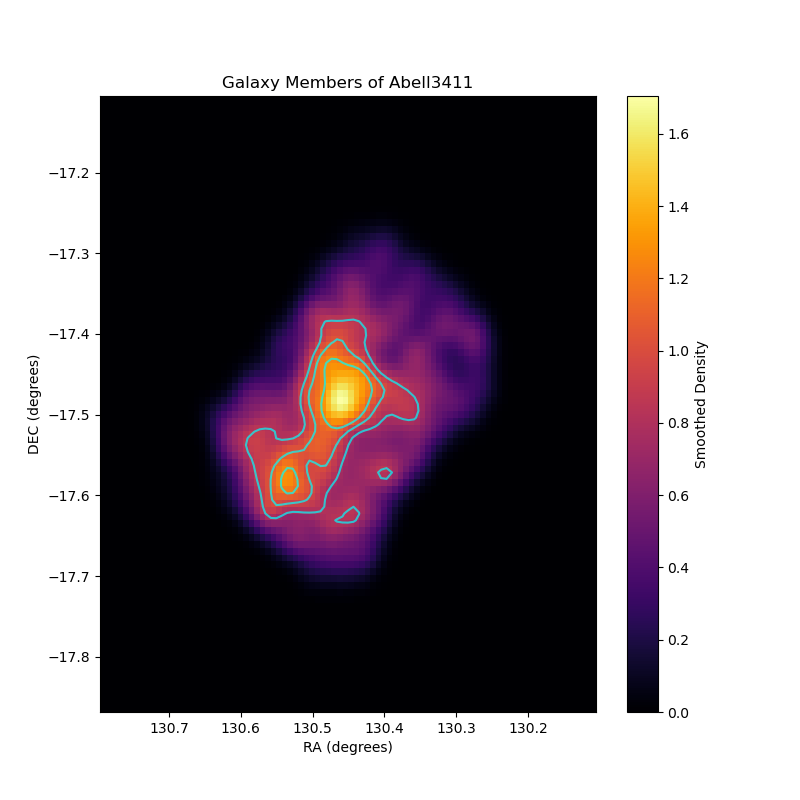

Actual members plot saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing/members_graph/Abell3411/Abell3411_actual_members.png
Contour level 1 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//actual_members/Abell3411/contours_ra_dec/contour_level_1.csv
Contour level 2 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//actual_members/Abell3411/contours_ra_dec/contour_level_2.csv
Contour level 3 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//actual_members/Abell3411/contours_ra_dec/contour_level_3.csv


/var/folders/7s/vm2shg2x4yq_97b8jbnb1y8r0000gn/T/ipykernel_43984/2314112922.py:110: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for i, collection in enumerate(members_cs.collections):


In [17]:
import os
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from scipy.ndimage import gaussian_filter
from shapely.geometry import Point, Polygon
import pyregion

def separate_catalog_by_regions(reg_file, catalog):
    # Read the region file with pyregion
    print(f"Reading regions from {reg_file}")
    regions = pyregion.open(reg_file)
    print(f"Found {len(regions)} regions")
    
    # Convert regions to shapely polygons
    print("Converting regions to polygons...")
    polygons = []
    for reg in regions:
        if reg.name == "polygon":
            # Extract the polygon vertices
            vertices = reg.coord_list
            points = [(vertices[i], vertices[i+1]) for i in range(0, len(vertices), 2)]
            polygons.append(Polygon(points))
    
    print(f"Converted {len(polygons)} polygons")
    
    
    # Using X_IMAGE and Y_IMAGE columns
    x_col = 'XWIN_IMAGE'
    y_col = 'YWIN_IMAGE'
    print(f"Using {x_col} and {y_col} as pixel coordinate columns")
    
    # Check each object against all polygons
    in_region_mask = np.zeros(len(catalog), dtype=bool)
    
    for i, (x, y) in enumerate(zip(catalog[x_col], catalog[y_col])):
        if i % 1000 == 0:  # Progress indicator
            print(f"Checking object {i}/{len(catalog)}")
        
        # Create a Point for the current object
        point = Point(x, y)
        
        # Check if the point is inside any polygon
        for polygon in polygons:
            if polygon.contains(point):
                in_region_mask[i] = True
                break
    
    # Create the two catalogs
    inside_catalog = catalog[in_region_mask]
    outside_catalog = catalog[~in_region_mask]
    
    return inside_catalog, outside_catalog, in_region_mask

nonmembers, members, region_mask = separate_catalog_by_regions(f"{datadir}data/region_files/{cluster_name}_b_starmask_physical.reg", colors_mags[wg])

# Get RA and DEC
ra = members['ra']
dec = members['dec']

# 2D histogram
counts, xedges, yedges = np.histogram2d(ra, dec, bins=hist_bins)
# do 5 galaxies per bin

# Padding
pad = 20
padded_counts = np.pad(counts, pad_width=pad, mode='constant', constant_values=0)

# Smoothing
smoothed_padded_counts = gaussian_filter(padded_counts, sigma=hist_sigma)

# Plot smoothed histogram
plt.figure(figsize=(8, 8))
nx, ny = smoothed_padded_counts.shape
dx = xedges[1] - xedges[0]
dy = yedges[1] - yedges[0]
xedges_padded = np.linspace(xedges[0] - pad * dx, xedges[-1] + pad * dx, smoothed_padded_counts.shape[0] + 1)
yedges_padded = np.linspace(yedges[0] - pad * dy, yedges[-1] + pad * dy, smoothed_padded_counts.shape[1] + 1)
extent = [xedges_padded[0], xedges_padded[-1], yedges_padded[0], yedges_padded[-1]]

plt.imshow(smoothed_padded_counts.T, extent=extent, origin='lower', cmap='inferno', aspect='auto', vmin=smoothed_padded_counts.min(), vmax=smoothed_padded_counts.max())
plt.gca().invert_xaxis()
plt.colorbar(label='Smoothed Density')
plt.title(f'Galaxy Members of {cluster_name}')
plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')

# Contours
contour_levels = np.linspace(np.percentile(smoothed_padded_counts, members_contour_percentiles[0]), np.percentile(smoothed_padded_counts, members_contour_percentiles[1]), members_contour_number)

# Contour Colors
colors = ['cyan', 'cyan', 'cyan']
x_padded, y_padded = np.meshgrid(xedges_padded[:-1], yedges_padded[:-1])
members_cs = plt.contour(x_padded, y_padded, smoothed_padded_counts.T, levels=contour_levels, colors=colors, linewidths=1.5, alpha=0.7)

# Save and show the image
save_path = f"/Users/leilaohashi/gitrepo/leila_superbit_lensing/members_graph/{cluster_name}/{cluster_name}_actual_members.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Actual members plot saved to {save_path}")

# save contours
save_dir = f'{datadir}/actual_members/{cluster_name}/contours_ra_dec'
os.makedirs(save_dir, exist_ok=True)

all_members_vertices_ra = []
all_members_vertices_dec = []

for i, collection in enumerate(members_cs.collections):

    contour_save_path = os.path.join(save_dir, f'contour_level_{i+1}.csv')

    with open(contour_save_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['RA', 'Dec'])

        for path in collection.get_paths():
            contour_points = path.vertices
            ax.scatter(contour_points[:, 0], contour_points[:, 1], s=2, color='red', alpha=0.7)
            all_members_vertices_ra.extend(contour_points[:,0])
            all_members_vertices_dec.extend(contour_points[:,1])
            writer.writerows(contour_points)
    print(f"Contour level {i+1} saved to {contour_save_path}")

all_members_vertices_ra = np.array(all_members_vertices_ra)
all_members_vertices_dec = np.array(all_members_vertices_dec)

In [18]:
# scatter red sequence galaxies
redseq_ra = colors_mags[wg]['ra']
redseq_dec = colors_mags[wg]['dec']
redseq_ra = np.array(redseq_ra)
redseq_dec = np.array(redseq_dec)

# scatter member galaxies
member_ra = members['ra']
member_dec = members['dec']
member_ra = np.array(member_ra)
member_dec = np.array(member_dec)

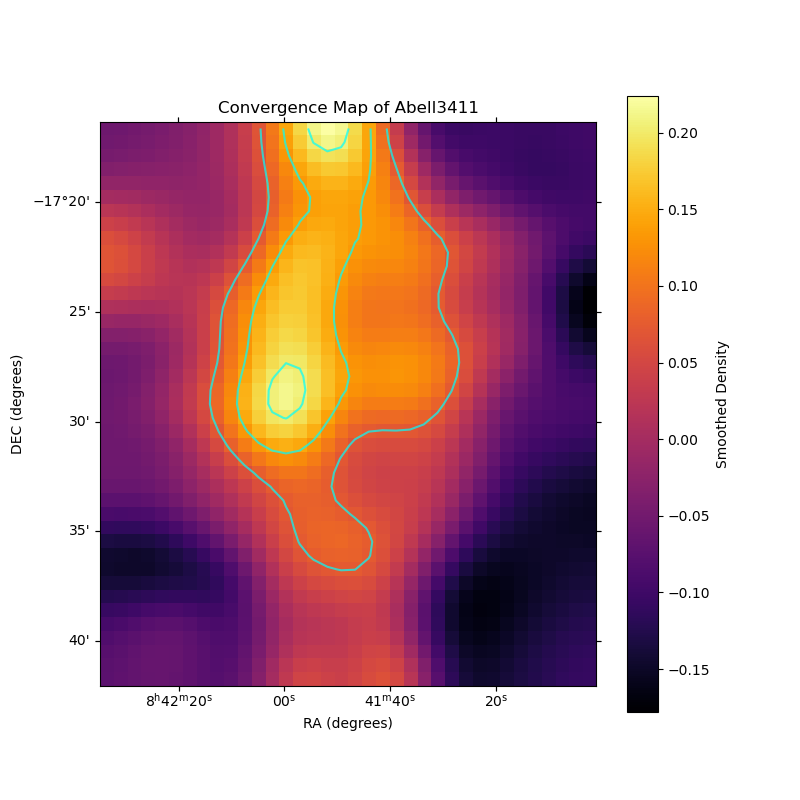

Convergence plot saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing/convergence_graph/Abell3411/Abell3411_convergence_graph.png
Contour level 1 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//conv_contours/Abell3411/contours_ra_dec/contour_level_1.csv
Contour level 2 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//conv_contours/Abell3411/contours_ra_dec/contour_level_2.csv
Contour level 3 saved to /Users/leilaohashi/gitrepo/leila_superbit_lensing//conv_contours/Abell3411/contours_ra_dec/contour_level_3.csv


/var/folders/7s/vm2shg2x4yq_97b8jbnb1y8r0000gn/T/ipykernel_43984/3962705687.py:54: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for i, collection in enumerate(conv_cs.collections):


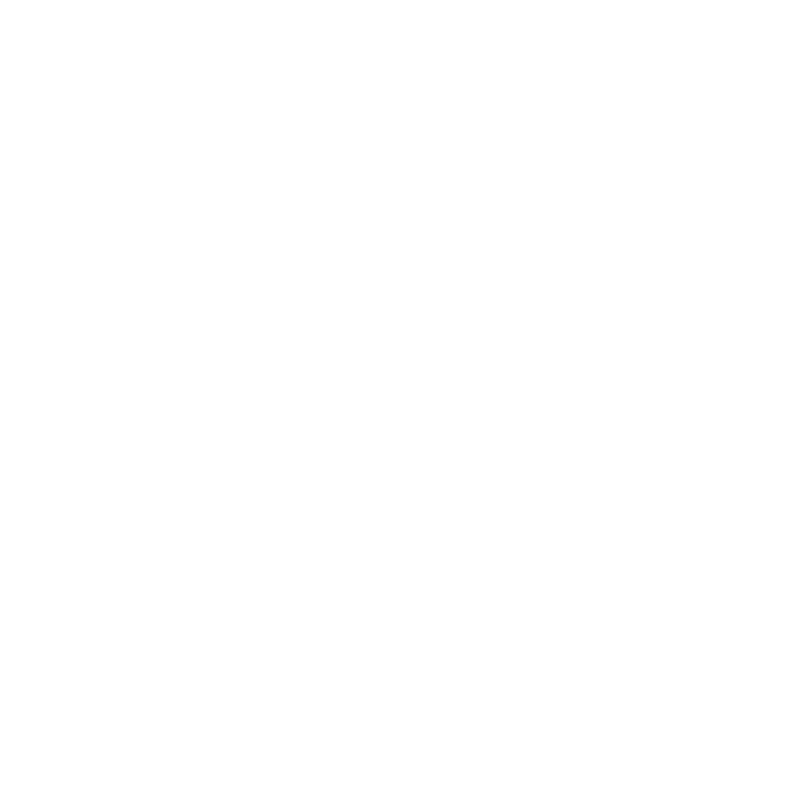

In [24]:
import os
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from scipy.ndimage import gaussian_filter

fits_path = f"{datadir}/data/convergence_maps/kappa_{cluster_name}_b.fits"
if not os.path.exists(fits_path):
    print(f"Convergence map for {cluster_name} not found at {fits_path}.")

# Open the image
conv_hdu = fits.open(fits_path)[0]
conv_data = conv_hdu.data
conv_data = np.array(conv_data)
conv_header = conv_hdu.header
conv_wcs = WCS(conv_header)

# Smoothing
smoothed_conv = gaussian_filter(conv_data, sigma=hist_sigma)

# Plot smoothed histogram
plt.figure(figsize=(8, 8))
nx, ny = smoothed_conv.shape

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(projection=conv_wcs)
im = ax.imshow(smoothed_conv, origin='lower', cmap='inferno')
plt.colorbar(im, ax=ax, label='Smoothed Density')
plt.title(f'Convergence Map of {cluster_name}')
plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')

# Contours
contour_levels = np.linspace(np.percentile(smoothed_conv, conv_contour_percentiles[0]), np.percentile(smoothed_conv, conv_contour_percentiles[1]), conv_contour_number)

# Contour Colors
colors = ['cyan', 'cyan', 'cyan']
conv_cs = ax.contour(smoothed_conv, levels=contour_levels, colors=colors, linewidths=1.5, alpha=0.7)

# Save and show the image
save_path = f"/Users/leilaohashi/gitrepo/leila_superbit_lensing/convergence_graph/{cluster_name}/{cluster_name}_convergence_graph.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Convergence plot saved to {save_path}")

# save contours
save_dir = f'{datadir}/conv_contours/{cluster_name}/contours_ra_dec'
os.makedirs(save_dir, exist_ok=True)

conv_vertices_ra = []
conv_vertices_dec = []

for i, collection in enumerate(conv_cs.collections):

    contour_save_path = os.path.join(save_dir, f'contour_level_{i+1}.csv')

    with open(contour_save_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['RA', 'Dec'])

        for path in collection.get_paths():
            contour_points = path.vertices
            ax.scatter(contour_points[:, 0], contour_points[:, 1], s=2, color='red', alpha=0.7)
            conv_vertices = conv_wcs.wcs_pix2world(contour_points, 0)
            conv_vertices_ra.extend(conv_vertices[:,0])
            conv_vertices_dec.extend(conv_vertices[:,1])
            writer.writerows(contour_points)
    print(f"Contour level {i+1} saved to {contour_save_path}")

conv_vertices_ra = np.array(conv_vertices_ra)
conv_vertices_dec = np.array(conv_vertices_dec)

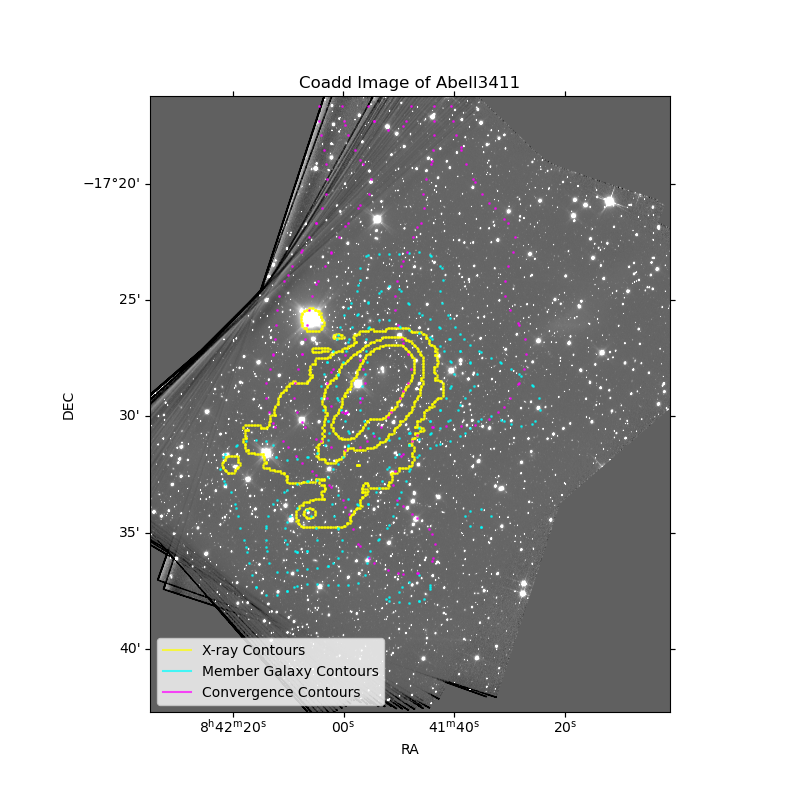

In [20]:
# Plotting contours on coadd image
import os
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from astropy.wcs import WCS
from matplotlib.lines import Line2D

def wcs_manual(header, prefer_tpv: bool = True) -> WCS:
    """
    Build a robust 2D celestial WCS from a FITS header.

    Parameters
    ----------
    header : astropy.io.fits.Header (or dict-like)
        FITS header containing WCS keywords.
    prefer_tpv : bool
        If True and the header indicates TPV and PV* terms exist, return WCS(header).
        If False, always return linear TAN WCS (ignoring TPV/PV).

    Returns
    -------
    wcs_manual : astropy.wcs.WCS
        A 2D WCS object.
    """

    # --- extract required keywords
    crpix1 = header.get("CRPIX1")
    crpix2 = header.get("CRPIX2")
    crval1 = header.get("CRVAL1")
    crval2 = header.get("CRVAL2")

    cd1_1 = header.get("CD1_1")
    cd1_2 = header.get("CD1_2", 0.0)
    cd2_1 = header.get("CD2_1", 0.0)
    cd2_2 = header.get("CD2_2")

    # Basic validation (fail early with helpful message)
    missing = []
    for k, v in [
        ("CRPIX1", crpix1), ("CRPIX2", crpix2),
        ("CRVAL1", crval1), ("CRVAL2", crval2),
        ("CD1_1", cd1_1), ("CD2_2", cd2_2),
    ]:
        if v is None:
            missing.append(k)
    if missing:
        raise KeyError(f"Header missing required WCS keywords: {missing}")

    # --- detect TPV + PV terms
    ctype1 = header.get("CTYPE1", "") or ""
    ctype2 = header.get("CTYPE2", "") or ""
    is_tpv = ("TPV" in ctype1) or ("TPV" in ctype2)
    has_pv_terms = any(str(k).startswith("PV") for k in header.keys())

    # If requested, try header WCS first when TPV+PV appear
    if prefer_tpv and is_tpv and has_pv_terms:
        try:
            w = WCS(header, naxis=2)
            # In some broken headers, WCS init succeeds but transform is unusable.
            # Quick sanity: if two pixels map to identical world coords, fallback.
            p = [[0.0, 0.0], [1000.0, 1000.0]]
            out = w.all_pix2world(p, 0)
            if (out[0][0] != out[1][0]) or (out[0][1] != out[1][1]):
                return w
        except Exception:
            # fall through to linear TAN
            pass

    # --- linear TAN fallback using CRPIX/CRVAL/CD
    wcs_manual = WCS(naxis=2)
    wcs_manual.wcs.crpix = [float(crpix1), float(crpix2)]
    wcs_manual.wcs.crval = [float(crval1), float(crval2)]
    wcs_manual.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    wcs_manual.wcs.cd = [
        [float(cd1_1), float(cd1_2)],
        [float(cd2_1), float(cd2_2)],
    ]
    return wcs_manual

fits_path = f'{datadir}data/coadds/{cluster_name}/{cluster_name}_coadd_b.sub.fits'
if not os.path.exists(fits_path):
    print(f"Coadd image for {cluster_name} not found at {fits_path}.")

# Open the image
coadd_hdu = fits.open(fits_path)[0]
coadd_header = coadd_hdu.header
coadd_data = coadd_hdu.data
wcs = wcs_manual(coadd_header)
ny, nx = coadd_data.shape # (height, width)
corners = np.array([[0, 0], [0, ny], [nx, 0], [nx, ny]])
coadd_radec = wcs.wcs_pix2world(corners, 0)


# plot the image
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection=wcs)
ax.imshow(coadd_data, origin='lower', cmap='gray', vmin=np.percentile(coadd_data, 1), vmax=np.percentile(coadd_data, 99))

# Grab and plot xray contours
ax.scatter(all_xray_vertices_ra, all_xray_vertices_dec, s=1, color='yellow', alpha=0.7, transform=ax.get_transform('world'))

# Grab and plot members contours
ax.scatter(all_members_vertices_ra, all_members_vertices_dec, s=1, color='cyan', alpha=0.7, transform=ax.get_transform('world'))

# Grab and plot convergence contours
ax.scatter(conv_vertices_ra, conv_vertices_dec, s=1, color='magenta', alpha=0.7, transform=ax.get_transform('world'))

# Aesthetics
ax.set_title(f'Coadd Image of {cluster_name}')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
ax.legend([Line2D([0], [0], color='yellow', lw=1.5, alpha=0.7), Line2D([0], [0], color='cyan', lw=1.5, alpha=0.7), Line2D([0], [0], color='magenta', lw=1.5, alpha=0.7)], ['X-ray Contours', 'Member Galaxy Contours', 'Convergence Contours'])
plt.show()


# add scatter of redseqence galaxies (new coadd)

# figure out how to make contours continuous

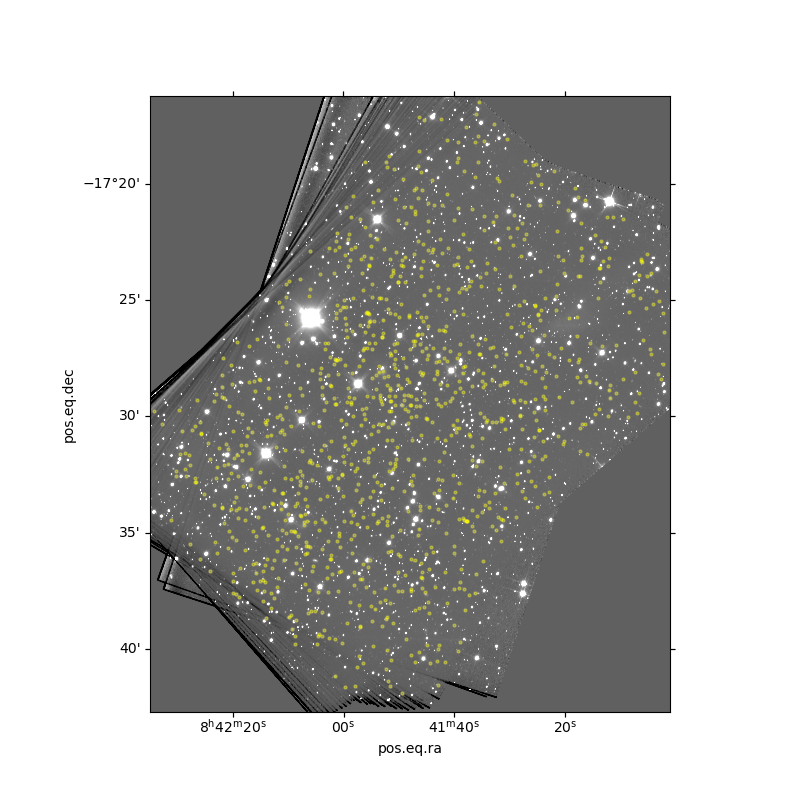

In [21]:
# Plotting contours on coadd image
import os
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from astropy.wcs import WCS
from matplotlib.lines import Line2D

def wcs_manual(header, prefer_tpv: bool = True) -> WCS:
    """
    Build a robust 2D celestial WCS from a FITS header.

    Parameters
    ----------
    header : astropy.io.fits.Header (or dict-like)
        FITS header containing WCS keywords.
    prefer_tpv : bool
        If True and the header indicates TPV and PV* terms exist, return WCS(header).
        If False, always return linear TAN WCS (ignoring TPV/PV).

    Returns
    -------
    wcs_manual : astropy.wcs.WCS
        A 2D WCS object.
    """

    # --- extract required keywords
    crpix1 = header.get("CRPIX1")
    crpix2 = header.get("CRPIX2")
    crval1 = header.get("CRVAL1")
    crval2 = header.get("CRVAL2")

    cd1_1 = header.get("CD1_1")
    cd1_2 = header.get("CD1_2", 0.0)
    cd2_1 = header.get("CD2_1", 0.0)
    cd2_2 = header.get("CD2_2")

    # Basic validation (fail early with helpful message)
    missing = []
    for k, v in [
        ("CRPIX1", crpix1), ("CRPIX2", crpix2),
        ("CRVAL1", crval1), ("CRVAL2", crval2),
        ("CD1_1", cd1_1), ("CD2_2", cd2_2),
    ]:
        if v is None:
            missing.append(k)
    if missing:
        raise KeyError(f"Header missing required WCS keywords: {missing}")

    # --- detect TPV + PV terms
    ctype1 = header.get("CTYPE1", "") or ""
    ctype2 = header.get("CTYPE2", "") or ""
    is_tpv = ("TPV" in ctype1) or ("TPV" in ctype2)
    has_pv_terms = any(str(k).startswith("PV") for k in header.keys())

    # If requested, try header WCS first when TPV+PV appear
    if prefer_tpv and is_tpv and has_pv_terms:
        try:
            w = WCS(header, naxis=2)
            # In some broken headers, WCS init succeeds but transform is unusable.
            # Quick sanity: if two pixels map to identical world coords, fallback.
            p = [[0.0, 0.0], [1000.0, 1000.0]]
            out = w.all_pix2world(p, 0)
            if (out[0][0] != out[1][0]) or (out[0][1] != out[1][1]):
                return w
        except Exception:
            # fall through to linear TAN
            pass

    # --- linear TAN fallback using CRPIX/CRVAL/CD
    wcs_manual = WCS(naxis=2)
    wcs_manual.wcs.crpix = [float(crpix1), float(crpix2)]
    wcs_manual.wcs.crval = [float(crval1), float(crval2)]
    wcs_manual.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    wcs_manual.wcs.cd = [
        [float(cd1_1), float(cd1_2)],
        [float(cd2_1), float(cd2_2)],
    ]
    return wcs_manual

fits_path = f'{datadir}data/coadds/{cluster_name}/{cluster_name}_coadd_b.sub.fits'
if not os.path.exists(fits_path):
    print(f"Coadd image for {cluster_name} not found at {fits_path}.")

# Open the image
coadd_hdu = fits.open(fits_path)[0]
coadd_header = coadd_hdu.header
coadd_data = coadd_hdu.data
wcs = wcs_manual(coadd_header)
ny, nx = coadd_data.shape # (height, width)
corners = np.array([[0, 0], [0, ny], [nx, 0], [nx, ny]])
coadd_radec = wcs.wcs_pix2world(corners, 0)


# plot the image
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection=wcs)
ax.imshow(coadd_data, origin='lower', cmap='gray', vmin=np.percentile(coadd_data, 1), vmax=np.percentile(coadd_data, 99))

# Plot red sequence galaxies
ax.scatter(redseq_ra, redseq_dec, s=5, color='blue', alpha=0.5, transform=ax.get_transform('world'), label='Red Sequence Galaxies')

# Plot member galaxies
ax.scatter(member_ra, member_dec, s=5, color='yellow', alpha=0.5, transform=ax.get_transform('world'), label='Member Galaxies')